In [77]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV






In [78]:
medic_insurance_df = pd.read_csv("../data/raw/02_medical_insurance_cost.csv")
medic_insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Objetivo
El objetivo de este proyecto es predecir `charges` (coste del seguro médico) a partir de caracteristicas del cliente `age`,`sex`,`bmi`,`children`,`smoker` y `region`


#### Información del dataset

In [79]:
medic_insurance_df.shape

(1338, 7)

In [80]:
medic_insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [81]:
medic_insurance_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


##### Duplicados y valores nulos

In [82]:
medic_insurance_df.duplicated().sum()

np.int64(1)

In [83]:
medic_insurance_df = medic_insurance_df.drop_duplicates()

In [84]:
medic_insurance_df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Una vez visrta la información y limpiar el dataset de duplicados y nulos vamos a separar las variables predictoras y el target

In [85]:
X = medic_insurance_df.drop(columns="charges")
y = medic_insurance_df["charges"]

#### EDA

Distribución de la variable objetivo

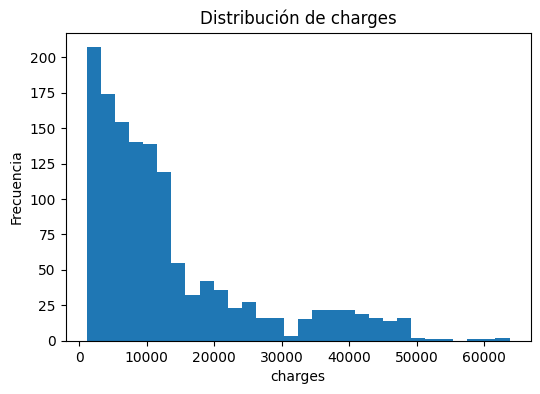

In [86]:
plt.figure(figsize=(6,4))
plt.hist(y, bins=30)
plt.title("Distribución de charges")
plt.xlabel("charges")
plt.ylabel("Frecuencia")
plt.show()

Relación de las variables numéricas con `charges`

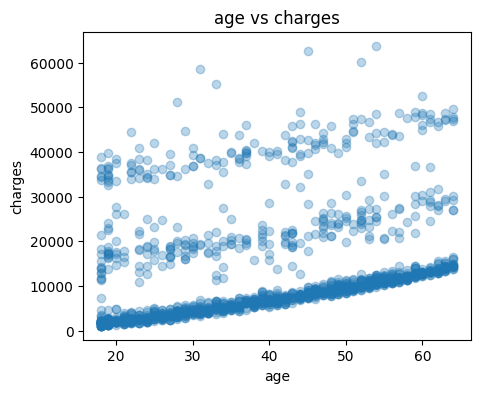

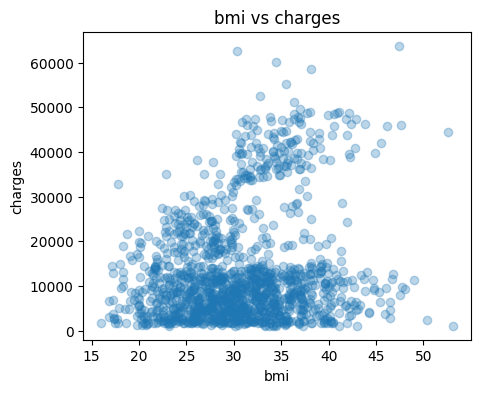

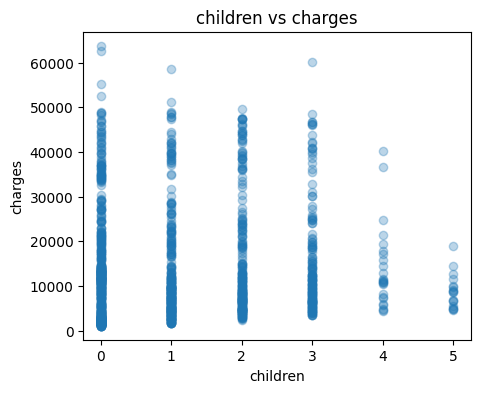

In [87]:
col_num = ["age", "bmi", "children"]

for col in col_num:
    plt.figure(figsize=(5,4))
    plt.scatter(medic_insurance_df[col], medic_insurance_df["charges"], alpha=0.3)
    plt.title(f"{col} vs charges")
    plt.xlabel(col)
    plt.ylabel("charges")
    plt.show()

Matriz de correlación 

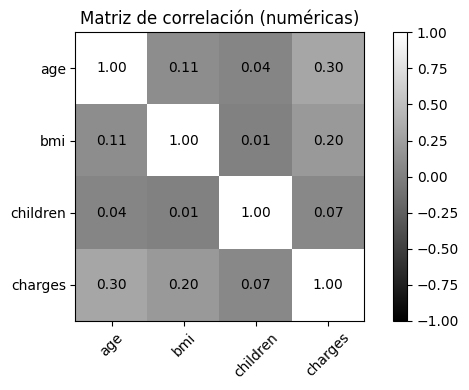

In [88]:
df_corr = medic_insurance_df[["age", "bmi", "children", "charges"]].corr()

plt.figure(figsize=(6,4))

plt.imshow(df_corr, interpolation="nearest", cmap="gray", vmin=-1, vmax=1)

plt.xticks(range(len(df_corr.columns)), df_corr.columns, rotation=45)
plt.yticks(range(len(df_corr.index)), df_corr.index)

for i in range(df_corr.shape[0]):
    for j in range(df_corr.shape[1]):
        plt.text(j, i, f"{df_corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar()        
plt.title("Matriz de correlación (numéricas)")
plt.tight_layout()
plt.show()

En las visualizaciones poodemos ver que la distribución de `charges` tiene un sesgo a la derecha que significa que hay muchos costes bajos y medios y pocos con costes muy altos.
En las relaciones podemos ver que entre `age vs charges` se aprecia una tendencia creciente: a mayor edad, mayor coste, además hay varias bandas que posiblemente corresponden a otra variable categorica, posiblemente `smoker`. Por otra parte la matriz de correlación indica que es la mas relacionada con nuestra variable objetivo. 

En la relación `bmi vs charges` se observan valores muy altos de `charges` en rangos de `bmi` medios-altos, así que influye pero no explica por si sola la variabilidad, teniendo una relación moderada en la matriz de correlación. Por último podemos ver que la relación `children vs charges` se relacionan muy poco.

Comparación de categoricas con `charge´

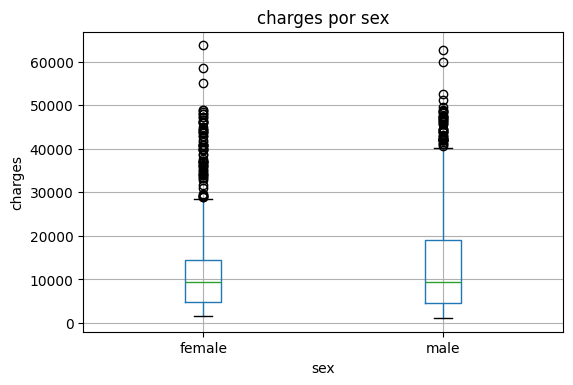

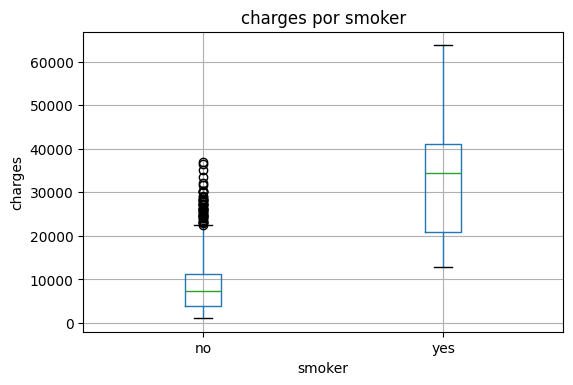

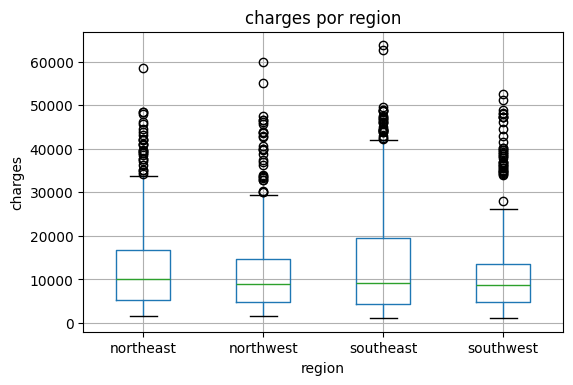

In [89]:
col_cat = ["sex", "smoker", "region"]

for col in col_cat:
    medic_insurance_df.boxplot(column="charges", by=col, figsize=(6,4))
    plt.title(f"charges por {col}")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel("charges")
    plt.show()


En el siguiente paso vamos a visualzar outliers de la variable objetivo.

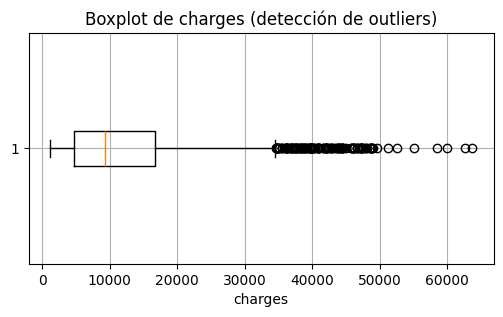

In [90]:
plt.figure(figsize=(6, 3))
plt.boxplot(medic_insurance_df["charges"], vert=False, showfliers=True)
plt.title("Boxplot de charges (detección de outliers)")
plt.xlabel("charges")
plt.grid(True)
plt.show()

En los boxplot podemos ver que hay valores extremos que confirman que la distribución de `charges` esta fuertemente sesgada a la derecha, estos valores no deben eliminarse porque corresponden a casos reales y relevantes.

En el boxplot `charges` x `smoker` la variable smoker separa dos grupos, no fumadores con mediana mucho más baja, con outliers puntuales. Y fumadores, mediana mucho más alta, mayor dispersión y valores máximos muy elevados. Esto indica que ser fumador es una variable muy influyente para predecir el coste del seguro.

#### División train/test

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### Preprocesado

En este dataset tenemos variables númericas y categóricas, como cada variable necesita un tratamiento distinto, usaremos `ColumnTransformer` para aplicar transformaciones diferentes por columnas en un solo paso.

Aplicaremos `StandardScaler` en númericas para estandarizar media ~ 0, y desviación standard ~1, recomendable para luego aplicar ridge/laso como mejora del modelo, ya que una variabilidad eleveda tendería a dominar la penalización.

Y aplicaremos `One_Hot encoder` para crear variables binarias por cada categoría sin introducir un orden artificial como `factorize()`. 

In [92]:
preprocess = ColumnTransformer(transformers=[("num", StandardScaler(), col_num),
                                             #handle_unknown para evitar errores si aparecen categorias no vistas durante el entrenamiento
                                             ("cat", OneHotEncoder(handle_unknown="ignore"), col_cat)])#handle_unknown para evitar errores si aparecen categorias no vistas durante el entrenamiento  

X_train_p = preprocess.fit_transform(X_train)#aprende parámetros y transforma
X_test_p = preprocess.transform(X_test)#solo transforma usando lo aprendido en train

#### Entrenamiento modelo Regresión Lineal

In [93]:
lr = LinearRegression()
lr.fit(X_train_p, y_train)

y_pred = lr.predict(X_test_p)
y_pred

array([ 8.14369388e+03,  5.73711568e+03,  1.43693149e+04,  3.17455136e+04,
        8.96238666e+03,  1.31497224e+04,  3.04467607e+04,  1.45328881e+03,
        1.06330184e+04,  1.13189438e+04,  1.03778536e+04,  3.31184377e+04,
        3.10772527e+04,  1.74119253e+04,  1.08016743e+04,  9.52889964e+03,
        4.16103784e+03,  3.17315373e+04,  3.21938875e+03,  5.22992460e+03,
        3.54979004e+03,  3.02837740e+04,  1.48989509e+04,  3.04569093e+04,
        3.11077668e+04,  5.51196081e+03,  3.55030401e+04,  3.65704810e+04,
        1.14123133e+04,  1.42056990e+04,  6.50234029e+03,  1.27246945e+04,
        3.99806590e+02,  1.20883980e+04,  3.96592069e+04,  1.23395540e+04,
        4.74412279e+03,  3.91903157e+03,  3.08606789e+04,  8.95870663e+03,
        7.05389441e+03,  3.01125636e+04,  3.47804324e+04,  1.22916189e+04,
        7.35739310e+03,  3.42060530e+03,  6.21243471e+03,  8.98345200e+03,
        4.26401828e+03,  9.01992870e+03,  6.60149578e+03,  1.20802337e+04,
        3.12447687e+04,  

#### Métricas del modelo

In [97]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

"MAE:", mae



('MAE:', 4177.045561036322)

In [98]:
"RMSE:", rmse


('RMSE:', 5956.342894363585)

In [99]:
"R2:", r2

('R2:', 0.8069287081198013)

##### Interpretación  de métricas
* MAE = 4,177--> El modelo se equivoca en 4,177 al estimar el coste del seguro

* RMSE = 5,956--> El error penalizando más los fallos grandes es de 5,956, lo que sugiere que existen casos con desviaciones importantes, (distribución sesgada y outliers en `charges`)

* R2 = 0,807--> para ser un modelo sin optimizar explica el 80,7% de la variabilidad de `charges` 

##### Optimización 

REgularización Ridge


In [95]:
ridge = Ridge()

param_grid = {"alpha": [0.01, 0.1, 1, 100]}

grid = GridSearchCV(estimator=ridge,
                    param_grid=param_grid,
                    scoring="r2",
                    cv=5,
                    n_jobs=-1)

grid.fit(X_train_p, y_train)

best_ridge = grid.best_estimator_
best_ridge

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


##### Evaluación

In [104]:
y_pred_ridge = best_ridge.predict(X_test_p)

mae_r = mean_absolute_error(y_test, y_pred_ridge)
rmse_r = root_mean_squared_error(y_test, y_pred_ridge)
r2_r = r2_score(y_test, y_pred_ridge)

grid.best_params_

{'alpha': 1}

In [101]:
mae_r

4185.406966823999

In [105]:
rmse_r

5964.276525877431

In [103]:
r2_r

0.8064140377474764

#### Conclusión
El objetivo del proyecto a sido predecir el coste de un seguro médico a partir de variables fisiologicas y demograficas. En el EDA se a comprobado la calidad de los datos y detección de patrones relevantes. En las visualizaciones se muestra que la variable objetivo tiene una distribución fuertemente sesgada a la dercha con outliers, esto es normal por los costes del seguro ddel dataset. Al comparar `charges` con smoker, se observa un separación muy clara entre fumadores y no fumadores.

Resultados optimizados:

La comparación muestra que Ridge no mejora al baseline (incluso empeora ligeramente el MAE), por lo que la regularización no aporta beneficio relevante. 
En conclusión, el modelo base ya ofrece un modelo solido (r1=0,8) pero la optimización no mejora los resultados. Dado el sesgo y los outliers observados en la variable objetivo se podría utilizar como futura mejora `log1p` para estabilizar la varianza y reducir el impacto de los costes extremadamente altos en los errores.
 